In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Generating data from -5 to 5 with non-linearity to study Underfitting

In [2]:
np.random.seed(0)
X = np.linspace(-5, 5, 200).reshape(-1, 1)
y = X**2 + np.random.randn(200, 1) * 3

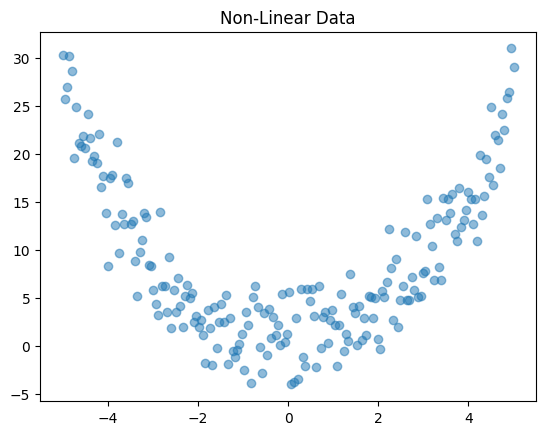

In [10]:
plt.scatter(X, y, alpha=0.5)
plt.title("Non-Linear Data")
plt.show()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3) # 30 percent of the total data is used while testing

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [6]:
def print_metrics(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}  R2: {r2:.4f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")


In [7]:
print("UNDERFITTING CASE")
print_metrics(y_train, y_train_pred, "Train")
print_metrics(y_test, y_test_pred, "Test")

UNDERFITTING CASE
Train  R2: 0.0110, MSE: 61.60, RMSE: 7.85
Test  R2: -0.0712, MSE: 82.64, RMSE: 9.09


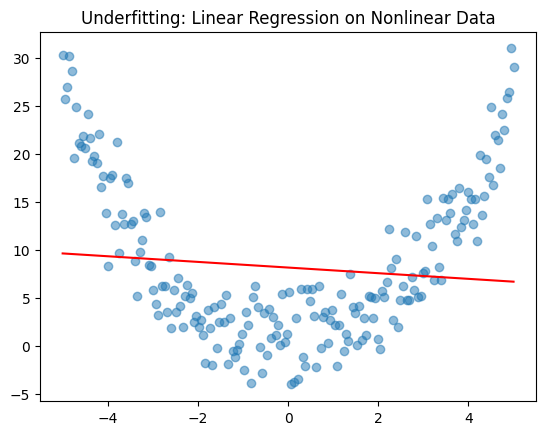

In [8]:
plt.scatter(X, y, alpha=0.5)
plt.plot(X, model.predict(X), color='red')
plt.title("Underfitting: Linear Regression on Nonlinear Data")
plt.show()